# NOTEBOOK VISUALIZACIÓN MEJOR MODELO

In [18]:
from Distance import manhattan_distance
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
from src.FungiClustering import FungiInspiredClustering
from sklearn.metrics import silhouette_score,davies_bouldin_score
import pandas as pd

In [19]:
df=pd.read_csv(r'../src/Pruebas/CleanDataset.csv')

In [20]:
df = df.drop(
    columns=['MINIMUM_PAYMENTS', 'CASH_ADVANCE_TRX', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'TENURE', 'PRC_FULL_PAYMENT',
             'PURCHASES'])
df

,BALANCE,BALANCE_FREQUENCY,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,CASH_ADVANCE_FREQUENCY,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS
0,40.900749,0.818182,0.00,95.40,0.000000,0.166667,0.000000,0.000000,2.0,1000.0,201.802084
1,3202.467416,0.909091,0.00,0.00,6442.945483,0.000000,0.000000,0.250000,0.0,7000.0,4103.032597
2,2495.148862,1.000000,773.17,0.00,0.000000,1.000000,1.000000,0.000000,12.0,7500.0,622.066742
3,1666.670542,0.636364,1499.00,0.00,205.788017,0.083333,0.083333,0.083333,1.0,7500.0,0.000000
4,817.714335,1.000000,16.00,0.00,0.000000,0.083333,0.083333,0.000000,1.0,1200.0,678.334763
...,...,...,...,...,...,...,...,...,...,...,...
8945,28.493517,1.000000,0.00,291.12,0.000000,1.000000,0.000000,0.000000,6.0,1000.0,325.594462
8946,19.183215,1.000000,0.00,300.00,0.000000,1.000000,0.000000,0.000000,6.0,1000.0,275.861322
8947,23.398673,0.833333,0.00,144.40,0.000000,0.833333,0.000000,0.000000,5.0,1000.0,81.270775
8948,13.457564,0.833333,0.00,0.00,36.558778,0.000000,0.000000,0.166667,0.0,500.0,52.549959


In [24]:
fungi_clustering = FungiInspiredClustering(manhattan_distance,n_clusters=3, max_iter=100, local_radius=0.5, global_radius=2.0)
fungi_clustering.fit(df.to_numpy())

# Asignar las etiquetas de clúster al dataframe
df['Cluster'] = fungi_clustering.labels

# Métricas de rendimiento
db_score = davies_bouldin_score(df.drop(columns=['Cluster']), df['Cluster'])
print(f"Davies-Bouldin Score: {db_score}\n")
silhouette_avg = silhouette_score(df.to_numpy(), df['Cluster'])
print(f"Coeficiente de Silhouette: {silhouette_avg}")

# Imprimir datos de centroides y asignaciones
print(f"\nCentroides finales:\n{fungi_clustering.centroids}\n")

# Tamaño de cada clúster
cluster_sizes = df['Cluster'].value_counts().sort_index()
print(f"Tamaño de cada clúster:\n{cluster_sizes}\n")


Davies-Bouldin Score: 1.0544794118761194

Coeficiente de Silhouette: 0.5258192298952107

Centroides finales:
[[ 5.62886934e+03  2.55720503e+00  9.55418081e+03  2.85152096e+03
   7.94133456e+03  1.73159708e+00  5.58587217e-01  1.58545528e+00
   6.91966998e+01  1.44689226e+04  2.38385185e+04 -1.83964463e+00]
 [ 4.91048155e+03  1.65797151e+00  1.24951496e+03  7.44055010e+02
   3.13569142e+03 -9.69317053e-01  1.94110184e+00 -1.03989556e-01
   2.81760544e+01  9.99854214e+03  3.92818643e+03  1.49665704e+00]
 [ 9.65735953e+02 -7.26571877e-01  4.04624747e+02  3.35894169e+02
   5.56408356e+02 -4.26286342e-01  1.29184801e+00 -1.24196974e+00
   1.40866406e+01  3.48156527e+03  1.17307502e+03  3.77102243e+00]]

Tamaño de cada clúster:
Cluster
0      66
1    1280
2    7604
Name: count, dtype: int64



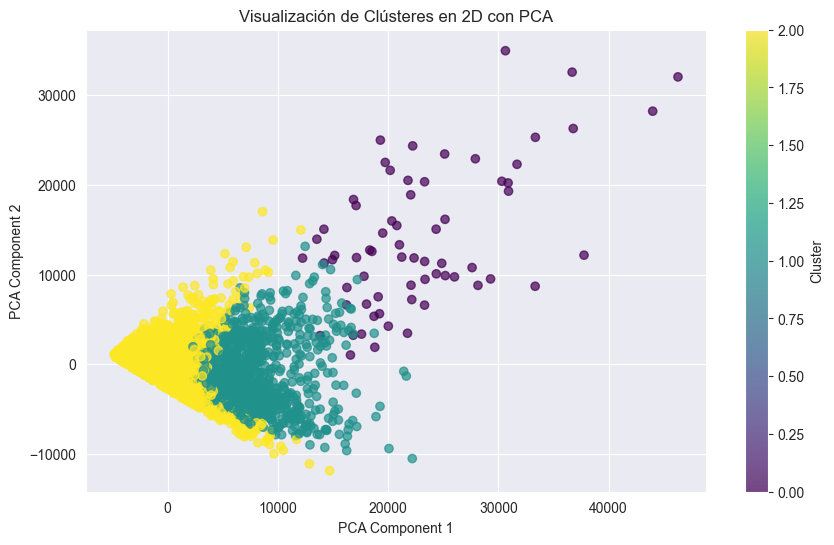

In [27]:
# Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2)
pca_result = pca.fit_transform(df.dropna().drop('Cluster', axis=1))  

# Agregar las etiquetas de los clústeres al DataFrame transformado
df_pca = pd.DataFrame(pca_result, columns=['PCA1', 'PCA2'])
df_pca['Cluster'] = df['Cluster']  # Asignar las etiquetas de clúster

# Visualizar los resultados
plt.figure(figsize=(10, 6))
plt.scatter(df_pca['PCA1'], df_pca['PCA2'], c=df_pca['Cluster'], cmap='viridis', alpha=0.7)
plt.colorbar(label='Cluster')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Visualización de Clústeres en 2D con PCA')
plt.show()
